In [0]:
storage_account_name = "librarydatastorage2"
storage_account_key = "<YOUR_STORAGE_KEY>"

spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
    storage_account_key
)

In [0]:
path = "abfss://raw@librarydatastorage2.dfs.core.windows.net/processed/features_v1"

df = spark.read.parquet(path)

In [0]:
path = "abfss://raw@librarydatastorage2.dfs.core.windows.net/processed/features_v1"

df = spark.read.parquet(path)

In [0]:
df.printSchema()
df.show(5)

root
 |-- building_id: integer (nullable = true)
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- meter: integer (nullable = true)
 |-- meter_reading: double (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: double (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- floor_count: double (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- precip_depth_1_hr: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)

+-----------+-------+-------------------+-----+-------------+-----------+-----------+----------+-----------+---------------+--------------+---------------+-----------------+------------------+--------------+----------+
|building_id|site_id|          timestamp|meter|meter_reading|prim

In [0]:
df.describe().show()

+-------+-----------------+------------------+------------------+------------------+-----------+------------------+-----------------+-----------------+------------------+------------------+-----------------+--------------------+------------------+------------------+------------------+
|summary|      building_id|           site_id|             meter|     meter_reading|primary_use|       square_feet|       year_built|      floor_count|   air_temperature|    cloud_coverage|  dew_temperature|   precip_depth_1_hr|sea_level_pressure|    wind_direction|        wind_speed|
+-------+-----------------+------------------+------------------+------------------+-----------+------------------+-----------------+-----------------+------------------+------------------+-----------------+--------------------+------------------+------------------+------------------+
|  count|         20216100|           2263477|          20216100|          20216100|    2263477|           2263477|          2263477|         

In [0]:
from pyspark.sql.functions import col

df.select([
    (col(c).isNull().cast("int")).alias(c) for c in df.columns
]).groupBy().sum().show()

+----------------+------------+--------------+----------+------------------+----------------+----------------+---------------+----------------+--------------------+-------------------+--------------------+----------------------+-----------------------+-------------------+---------------+
|sum(building_id)|sum(site_id)|sum(timestamp)|sum(meter)|sum(meter_reading)|sum(primary_use)|sum(square_feet)|sum(year_built)|sum(floor_count)|sum(air_temperature)|sum(cloud_coverage)|sum(dew_temperature)|sum(precip_depth_1_hr)|sum(sea_level_pressure)|sum(wind_direction)|sum(wind_speed)|
+----------------+------------+--------------+----------+------------------+----------------+----------------+---------------+----------------+--------------------+-------------------+--------------------+----------------------+-----------------------+-------------------+---------------+
|               0|    17952623|             0|         0|                 0|        17952623|        17952623|       17952623|       

In [0]:
display(df.select("meter_reading"))

meter_reading
206.018
91.1954
0.0
470.833
587.0
131.814
124.09100000000001
507.952
1899.2
25267.5


In [0]:
df.select("meter_reading", "air_temperature").show(100)

+------------------+---------------+
|     meter_reading|air_temperature|
+------------------+---------------+
|           206.018|           NULL|
|           91.1954|           NULL|
|               0.0|           NULL|
|           470.833|           NULL|
|             587.0|           NULL|
|           131.814|           NULL|
|124.09100000000001|           NULL|
|           507.952|           NULL|
|            1899.2|           NULL|
|           25267.5|           NULL|
|           7172.17|           NULL|
|             295.0|           NULL|
|           3244.32|           NULL|
|           150.649|           NULL|
|             486.1|           NULL|
|            6107.6|           NULL|
|           2886.59|           NULL|
|           118.008|           NULL|
|           864.677|           NULL|
|           429.051|           NULL|
|           735.872|           NULL|
|            8757.3|           NULL|
|           3407.71|           NULL|
|           817.547|           NULL|
|

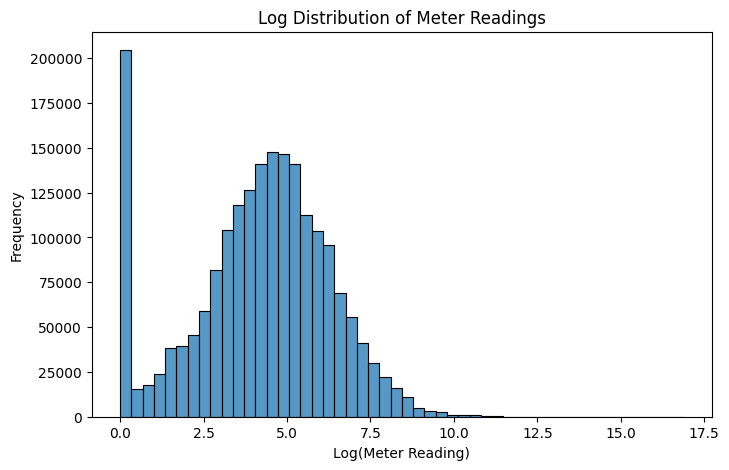

In [0]:
import numpy as np

df_pd["log_meter"] = np.log1p(df_pd["meter_reading"])

plt.figure(figsize=(8,5))
sns.histplot(df_pd["log_meter"], bins=50)

plt.title("Log Distribution of Meter Readings")
plt.xlabel("Log(Meter Reading)")
plt.ylabel("Frequency")

plt.show()

This visualization shows the log-transformed distribution of meter_reading.
The original data is highly skewed, with many low values and a few extremely high values.
After applying a log transformation, the distribution becomes more balanced and easier to interpret.
A large number of zero values are also observed, indicating periods of no energy consumption.

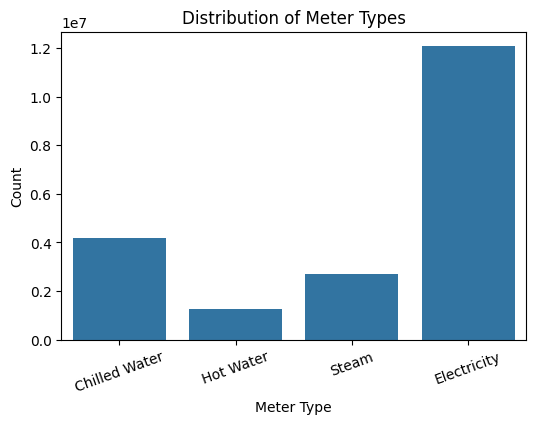

In [0]:
meter_pd["meter_type"] = meter_pd["meter"].map({
    0: "Electricity",
    1: "Chilled Water",
    2: "Steam",
    3: "Hot Water"
})

plt.figure(figsize=(6,4))
sns.barplot(x="meter_type", y="count", data=meter_pd)

plt.title("Distribution of Meter Types")
plt.xlabel("Meter Type")
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.show()

This visualization shows the distribution of different meter types in the dataset. 
Electricity (meter type 0) has the highest number of records, indicating that most energy consumption measurements are related to electrical usage. 
Other meter types such as chilled water, steam, and hot water appear less frequently, suggesting that they are either less common or recorded for fewer buildings.

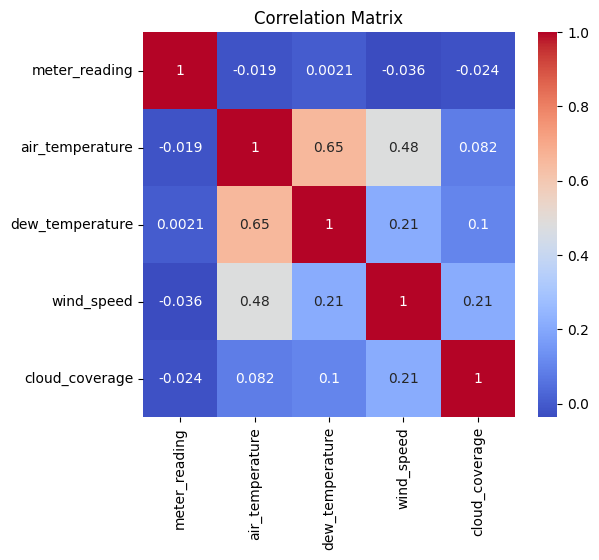

In [0]:
corr_pd = df.select(
    "meter_reading",
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "cloud_coverage"
).sample(fraction=0.05).toPandas()

plt.figure(figsize=(6,5))
sns.heatmap(corr_pd.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

This correlation matrix shows the relationships between energy consumption (meter_reading) and weather-related features. 
The results indicate that meter_reading has very weak correlation with individual environmental variables such as air temperature, wind speed, and cloud coverage. 
However, there is a stronger relationship between some weather variables themselves, such as air temperature and dew temperature. 
This suggests that energy consumption is influenced by multiple factors rather than a single variable, and more complex patterns may exist in the data.